# 01. 데이터 구조 파악

시간축 분포, 결측 블록 구조, 카디널리티, 변수군 성격을 확인한다.
여기서 나오는 그림들이 **보고서 §2 (데이터)** 가 된다.

> 비용 관점의 탐색(금액 분포, 손실 집중도)은 `02_eda_cost_relevant` 에서 별도로 다룬다.
> 목적 함수가 금액 가중이므로 '사기 건수'가 아니라 '사기 금액'을 봐야 하기 때문이다.

In [1]:
import sys
from pathlib import Path

# src/ 를 import 경로에 추가 (uv pip install -e . 를 했다면 불필요)
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제별 폰트 설정 (예: 윈도우 맑은 고딕, 맥 애플고딕)
import matplotlib.font_manager as fm
import platform

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    # Colab의 경우 나눔고딕 설치 후 적용 필요
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False



from frauddetectionreport import config, data
from frauddetectionreport.config import TARGET, TIME_COL, AMOUNT_COL

train = data.load("train")
groups = data.column_groups(train)
print(train.shape)

(590540, 434)


## 1. 시간축

거래량과 사기율이 기간에 따라 어떻게 변하는지 본다.
**사기율이 시간에 따라 변한다면** 랜덤 split은 여러 기간과 반복 개체를 섞어
운영 시점보다 낙관적일 수 있으므로 시간 기반 split이 필요하다 (03에서 실증).

Task was destroyed but it is pending!
task: <Task pending name='Task-299' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-300' coro=<Kernel.shell_main() running at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\fraudDetectionReport\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
C:\fraudDetectionReport\.venv\Lib\site-packages\matplotlib\cbook.py:273: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  self._pickled_cids = set()
Task was destroyed but it is pending!
task: <Task pending name='Task-300' coro=<Kernel.shell_main() running at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-384' coro=<_async_in_context

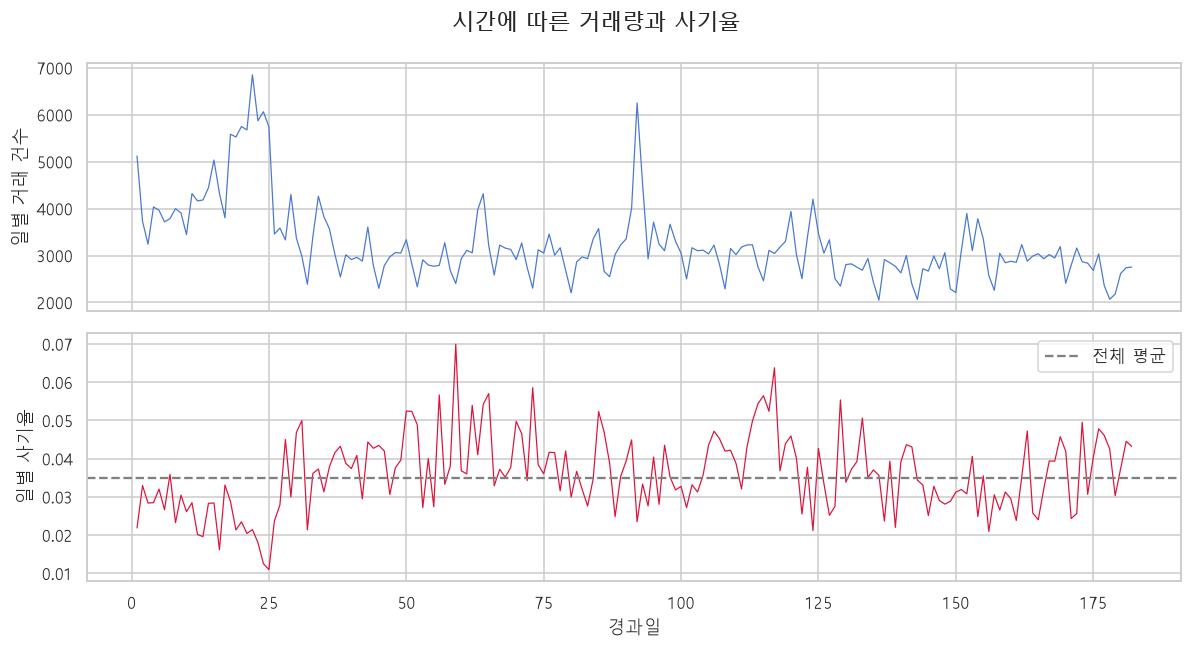

사기율 범위: 0.0110 ~ 0.0699


In [28]:
day = (train[TIME_COL] // 86400).astype(int)
daily = train.groupby(day).agg(n=(TARGET, "size"), fraud_rate=(TARGET, "mean"))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(daily.index, daily["n"], lw=0.8)
axes[0].set_ylabel("일별 거래 건수")
axes[1].plot(daily.index, daily["fraud_rate"], lw=0.8, color="crimson")
axes[1].axhline(train[TARGET].mean(), ls="--", c="gray", label="전체 평균")
axes[1].set_ylabel("일별 사기율"); axes[1].set_xlabel("경과일"); axes[1].legend()
fig.suptitle("시간에 따른 거래량과 사기율", y=0.98)
plt.tight_layout(); plt.show()

print(f"사기율 범위: {daily.fraud_rate.min():.4f} ~ {daily.fraud_rate.max():.4f}")

### 시간대·요일 패턴

`TransactionDT` 를 시각/요일로 분해한다. 사기가 특정 시간대에 몰린다면
04에서 파생 변수로 만들 가치가 있다.

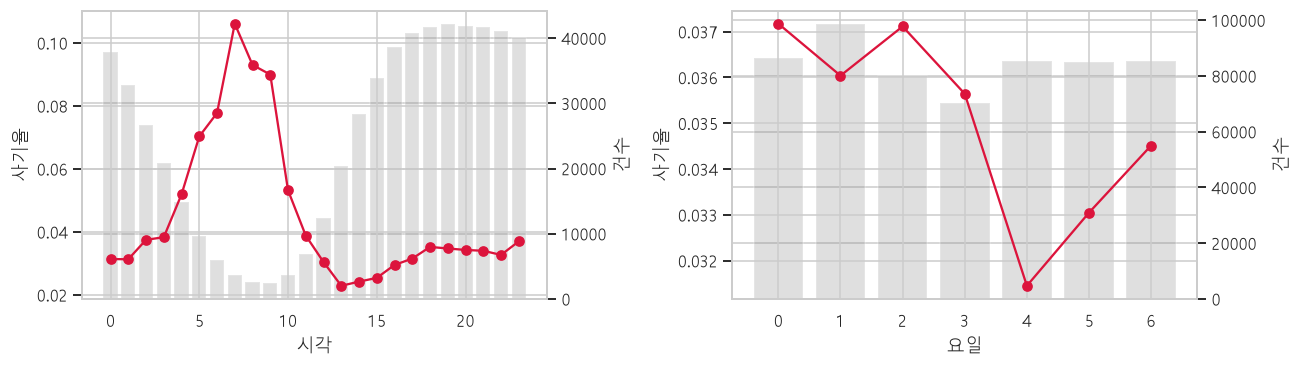

In [29]:
hour = (train[TIME_COL] // 3600 % 24).astype(int)
dow = (train[TIME_COL] // 86400 % 7).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (key, name) in zip(axes, [(hour, "시각"), (dow, "요일")]):
    g = train.groupby(key)[TARGET].agg(["mean", "size"])
    ax2 = ax.twinx()
    ax2.bar(g.index, g["size"], alpha=0.25, color="gray")
    ax.plot(g.index, g["mean"], "o-", color="crimson")
    ax.set_xlabel(name); ax.set_ylabel("사기율"); ax2.set_ylabel("건수")
    ax.set_zorder(2); ax.patch.set_visible(False)
plt.tight_layout(); plt.show()

## 2. 결측 구조

V 변수군의 결측이 블록 단위로 발생하는지 확인한다.
같이 비는 변수들은 같은 수집 경로를 공유한다는 뜻이므로,
그 그룹 자체가 하나의 정보가 된다.

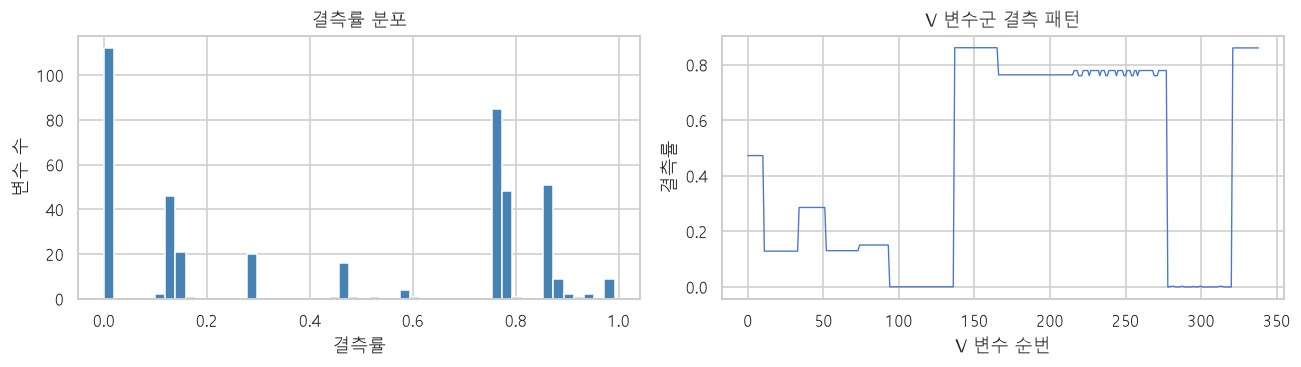

In [30]:
miss = data.missing_summary(train)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(miss.missing_rate, bins=50, color="steelblue")
axes[0].set_xlabel("결측률"); axes[0].set_ylabel("변수 수"); axes[0].set_title("결측률 분포")

# V 변수군의 결측 패턴이 블록을 이루는지
v_miss = train[groups["V"]].isna().mean()
axes[1].plot(range(len(v_miss)), v_miss.values, lw=0.9)
axes[1].set_xlabel("V 변수 순번"); axes[1].set_ylabel("결측률"); axes[1].set_title("V 변수군 결측 패턴")
plt.tight_layout(); plt.show()

In [31]:
# 결측 패턴이 동일한 변수들을 그룹으로 묶어본다.
# 계단 모양이 뚜렷하다면 블록 구조가 실재한다는 뜻.
# 거래축의 boolean을 bit-pack해 거대한 Python tuple 생성을 피한다.
packed = np.packbits(train[groups["V"]].isna().to_numpy(), axis=0).T
_, block_sizes = np.unique(packed, axis=0, return_counts=True)
blocks = pd.Series(block_sizes).sort_values(ascending=False)
print(f"V 변수 {len(groups['V'])}개가 결측 패턴 기준 {len(blocks)}개 그룹으로 묶임")
print(blocks.head(10))

V 변수 339개가 결측 패턴 기준 15개 그룹으로 묶임
9     46
0     43
2     32
10    31
5     23
4     22
3     20
11    19
12    18
14    18
dtype: int64


## 3. 카디널리티

`card1` 처럼 고유값이 1만 개 이상인 변수는 원-핫 인코딩이 불가능하고,
빈도 인코딩이나 타깃 인코딩이 필요하다 (04에서 처리).

In [32]:
cat_cols = [c for c in train.columns
            if train[c].dtype.name in ("object", "category") or c.startswith(("card", "addr"))]
card = (train[cat_cols].nunique()
        .sort_values(ascending=False)
        .to_frame("n_unique"))
card["missing_rate"] = train[cat_cols].isna().mean()
display(card.head(20))

,n_unique,missing_rate
card1,13553,0.000000
DeviceInfo,1786,0.799055
card2,500,0.015127
addr1,332,0.111264
id_33,260,0.875895
id_31,130,0.762451
card5,119,0.007212
card3,114,0.002650
id_30,75,0.868654
addr2,74,0.111264


## 4. 주요 범주형 변수의 사기율

`ProductCD`, `DeviceType`, 이메일 도메인 등에서 사기율이 크게 차이나는지 본다.
차이가 크다면 **06의 공정성 점검**에서 과차단 여부를 확인해야 할 세그먼트가 된다.

In [33]:
def seg_table(col, top=10, min_n=500):
    g = train.groupby(col, observed=True)[TARGET].agg(["size", "mean"])
    g = g[g["size"] >= min_n].sort_values("mean", ascending=False)
    g.columns = ["n", "fraud_rate"]
    return g.head(top)

for col in ["ProductCD", "DeviceType", "card4", "card6", "P_emaildomain"]:
    if col in train.columns:
        print(f"\n=== {col} ===")
        display(seg_table(col))


=== ProductCD ===


,n,fraud_rate
ProductCD,,
C,68519,0.116873
S,11628,0.058996
H,33024,0.047662
R,37699,0.037826
W,439670,0.020399



=== DeviceType ===


,n,fraud_rate
DeviceType,,
mobile,55645,0.101662
desktop,85165,0.065215



=== card4 ===


,n,fraud_rate
card4,,
discover,6651,0.077282
visa,384767,0.034756
mastercard,189217,0.034331
american express,8328,0.028698



=== card6 ===


,n,fraud_rate
card6,,
credit,148986,0.066785
debit,439938,0.024263



=== P_emaildomain ===


,n,fraud_rate
P_emaildomain,,
mail.com,559,0.189624
outlook.com,5096,0.094584
live.com.mx,749,0.054740
hotmail.com,45250,0.052950
gmail.com,228355,0.043542
icloud.com,6267,0.031434
comcast.net,7888,0.031187
charter.net,816,0.030637
bellsouth.net,1909,0.027763


## 5. C / D 변수군의 성격

익명화되어 의미를 알 수 없으나, 분포로부터 성격을 짐작할 수 있다.

- `C1~C14`: 카운팅 계열로 추정 (해당 카드에 연결된 주소 개수 등)
- `D1~D15`: 시간차 계열로 추정 (이전 거래로부터 경과일 등)

**`D1`은 04에서 카드 소유자 추정에 사용**하므로 특히 주의해서 본다.

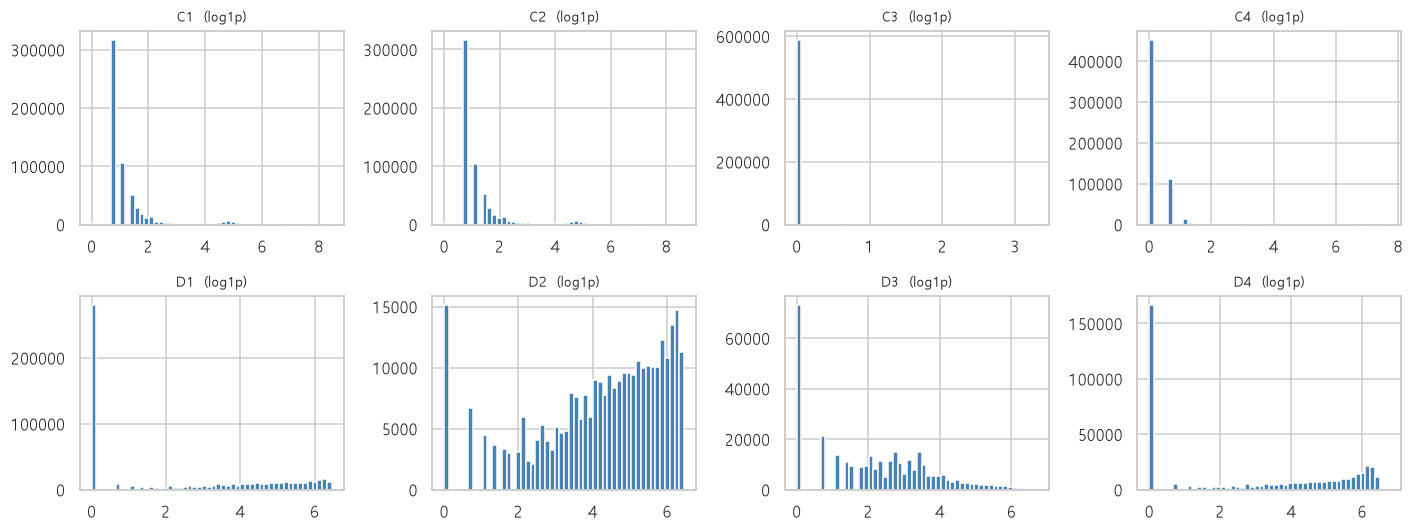

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5))
for ax, col in zip(axes.ravel(), groups["C"][:4] + groups["D"][:4]):
    s = train[col].dropna()
    ax.hist(np.log1p(s.clip(lower=0)), bins=50, color="steelblue")
    ax.set_title(f"{col}  (log1p)", fontsize=9)
plt.tight_layout(); plt.show()

## 요약

- 사기율의 시간 변동 → 시간 기반 split 필요성 (03에서 실증)
- V 변수군의 블록 결측 구조 확인
- 고카디널리티 범주형 확인 → 빈도 인코딩 필요 (04)
- 세그먼트별 사기율 격차 → 공정성 점검 대상 확정 (06)
- 다음: `02_eda_cost_relevant` — **비용 관점**의 탐색